# Part 1

# Task 1

### Imports

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Transition matrix

In [97]:
# Transition matrix
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, 0.986,  0.0050, 0.004, 0.005],
    [0.0000, 0.000,  0.9920, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, 0.991, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 1.000]
])

# Check that rows sum to 1
print(P.sum(axis=1))

[1. 1. 1. 1. 1.]


### Sample probabilties for transition and one woman lifetime simulation

In [98]:
def sample_next_state(probabilities, rng):
    """
    Input:
        probabilities: array of probabilities for the next state (rows of P)
        rng: random number generator
    Output:         next state (1 to 5)

    Direct method for sampling from a discrete distribution.
    States are numbered 1, ..., 5.
    """
    u = rng.random()
    cumulative = np.cumsum(probabilities) # cumulative distribution function
    return np.searchsorted(cumulative, u) + 1 # find the first index where cumulative exceeds u, +1 for 1-based state numbering


def simulate_one_woman(P, rng, check_month=60):
    """
    Simulate one woman from state 1 until death.
    Outputs:
        lifetime: number of months until death
        recurrence: whether any recurrence (local or distant) ever occurred
        local_recurrence: whether local recurrence ever occurred
        state_at_check: state at the validation month
    """
    state = 1
    lifetime = 0
    recurrence = False         # any cancer recurrence: local or distant
    local_recurrence = False   # local recurrence specifically
    state_at_check = None

    while state != 5:
        # Save state at validation month
        if lifetime == check_month:
            state_at_check = state

        # Move one month forward
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

        if state in [2, 3, 4]:
            recurrence = True

        if state in [2, 4]:
            local_recurrence = True

    # If death happened before the validation month, state remains 5
    if state_at_check is None:
        state_at_check = 5

    return lifetime,recurrence, local_recurrence, state_at_check

### Simulation settings

In [99]:
n = 1000 # number of women
seed = 1
check_month = 60   # for validation, e.g. after 5 years

rng = np.random.default_rng(seed) # we use system random number generator

lifetimes = np.zeros(n, dtype=int) # to store lifetimes of all women
recurrence = np.zeros(n, dtype=bool) # to store whether any recurrence occurred for each woman
local_recurrence = np.zeros(n, dtype=bool) # to store whether local recurrence occurred for each woman
states_at_check = np.zeros(n, dtype=int) # to store state at validation month for each woman

for i in range(n): # simulate one woman at a time and store results in the arrays
    lifetimes[i], recurrence[i], local_recurrence[i], states_at_check[i] = simulate_one_woman(
        P, rng, check_month=check_month
    )

### Summary of results

In [100]:
lifetime_summary = pd.DataFrame({
    "Mean lifetime (months)": [np.mean(lifetimes)],
    "Median lifetime (months)": [np.median(lifetimes)],
    "Std. dev. (months)": [np.std(lifetimes, ddof=1)],
    "Min": [np.min(lifetimes)],
    "25% quantile": [np.quantile(lifetimes, 0.25)],
    "75% quantile": [np.quantile(lifetimes, 0.75)],
    "Max": [np.max(lifetimes)]
})

lifetime_summary

,Mean lifetime (months),Median lifetime (months),Std. dev. (months),Min,25% quantile,75% quantile,Max
0,259.131,208.0,192.890224,1,117.75,354.0,1173


### Plot of simulation

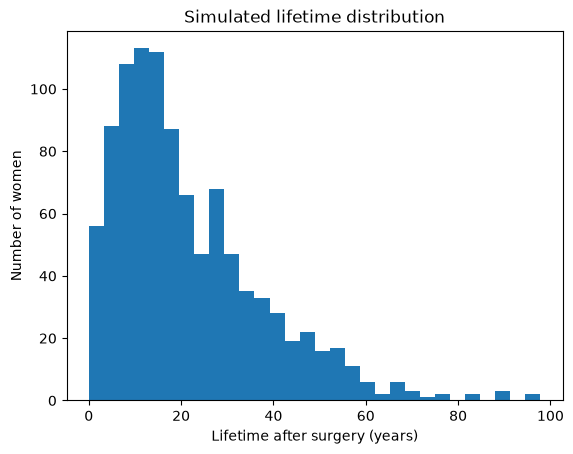

In [101]:
plt.hist(lifetimes / 12, bins=30)
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution")
plt.show()

In [102]:
prop_any_recurrence = np.mean(recurrence)
prop_local_recurrence = np.mean(local_recurrence)
prop_local_given_recurrence = np.sum(local_recurrence) / np.sum(recurrence)

print("Proportion with any recurrence:", prop_any_recurrence)
print("Proportion with local recurrence:", prop_local_recurrence)
print("Proportion local among those with recurrence:", prop_local_given_recurrence)

Proportion with any recurrence: 0.889
Proportion with local recurrence: 0.705
Proportion local among those with recurrence: 0.7930258717660292


### Validation

In [103]:
# Analytical distribution at check_month
p0 = np.array([1, 0, 0, 0, 0])
analytical = p0 @ np.linalg.matrix_power(P, check_month)

# Simulated distribution at check_month
counts = np.bincount(states_at_check, minlength=6)[1:]
simulated = counts / n

validation_table = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Simulated": simulated,
    "Analytical": analytical,
    "Difference": simulated - analytical
})

validation_table

,State,Simulated,Analytical,Difference
0,1,0.597,0.599188,-0.002188
1,2,0.162,0.154575,0.007425
2,3,0.108,0.116549,-0.008549
3,4,0.031,0.028794,0.002206
4,5,0.102,0.100895,0.001105


# Task 2

### More imports

In [104]:
from scipy.stats import chisquare

In [105]:
def simulate_state_at_t(P, t, rng): # simulate state at month t starting from state 1
    state = 1
    
    for _ in range(t):
        state = sample_next_state(P[state - 1], rng)
    
    return state

In [106]:
n = 1000
t = 120
rng = np.random.default_rng(1)

states_120 = np.zeros(n, dtype=int)

for i in range(n):
    states_120[i] = simulate_state_at_t(P, t, rng)

### Simulated distribution

In [107]:
observed_counts = np.bincount(states_120, minlength=6)[1:]
observed_distribution = observed_counts / n

observed_counts, observed_distribution

(array([352, 179, 161,  64, 244]), array([0.352, 0.179, 0.161, 0.064, 0.244]))

### Analytical distribution

In [108]:
p0 = np.array([1, 0, 0, 0, 0])

analytical_distribution = p0 @ np.linalg.matrix_power(P, t)
expected_counts = n * analytical_distribution

expected_counts, analytical_distribution

(array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
        248.18930075]),
 array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ]))

### Plot result

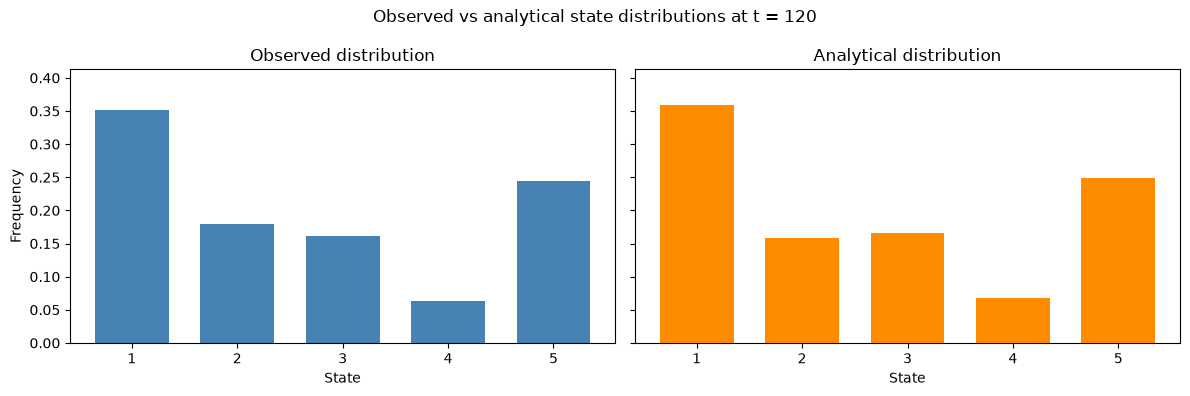

In [109]:
# Side-by-side bar charts for observed vs analytical distributions
states = np.arange(1, 6)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(states, observed_distribution, width=0.7, color="steelblue")
axes[0].set_title("Observed distribution")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(states)
axes[0].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

axes[1].bar(states, analytical_distribution, width=0.7, color="darkorange")
axes[1].set_title("Analytical distribution")
axes[1].set_xlabel("State")
axes[1].set_xticks(states)
axes[1].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

fig.suptitle("Observed vs analytical state distributions at t = 120")
fig.tight_layout()
plt.show()

### Comparrison

In [110]:
comparison = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Observed count": observed_counts,
    "Observed proportion": observed_distribution,
    "Expected proportion": analytical_distribution,
    "Expected count": expected_counts
})

comparison

,State,Observed count,Observed proportion,Expected proportion,Expected count
0,1,352,0.352,0.359026,359.026268
1,2,179,0.179,0.158956,158.956040
2,3,161,0.161,0.166087,166.086897
3,4,64,0.064,0.067741,67.741494
4,5,244,0.244,0.248189,248.189301


### Test

In [111]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 3.0981640968332864
p-value: 0.5415343741426009


The null hypothesis is that the simulated states at t = 120 follow the analytical
distribution p_120 = p_0 P^120. Since the p-value is not small, we do not reject
the null hypothesis. Therefore, the simulated distribution is consistent with the
analytical Markov chain distribution.

# Task 3

### Checking means

In [112]:
# Task 3: Phase-type distribution of lifetimes

Ps = P[:4, :4]      # transient-state transition matrix, states 1-4. Matrix of probabilities of moving between transient states (not including death)
ps = P[:4, 4]       # probabilities of dying from states 1-4

pi = np.array([1, 0, 0, 0])   # all women start in state 1
one = np.ones(4)

# Theoretical mean lifetime
theoretical_mean = pi @ np.linalg.inv(np.eye(4) - Ps) @ one

sample_mean = np.mean(lifetimes)

print("Sample mean lifetime:", sample_mean)
print("Theoretical mean lifetime:", theoretical_mean)
print("Difference:", sample_mean - theoretical_mean)

Sample mean lifetime: 259.131
Theoretical mean lifetime: 262.3716153127931
Difference: -3.2406153127931248


### Creating survival function to see theoretical vs simulated distrubution of lifetimes

In [113]:
def phase_type_survival(t, pi, Ps):
    """
    P(T > t), where T is lifetime in months.
    """
    return pi @ np.linalg.matrix_power(Ps, t) @ np.ones(Ps.shape[0])


def phase_type_bin_probability(a, b, pi, Ps):
    """
    Probability that lifetime T lies in the interval [a, b].
    If b is None, this means [a, infinity).
    """
    if b is None:
        return phase_type_survival(a - 1, pi, Ps)
    else:
        return phase_type_survival(a - 1, pi, Ps) - phase_type_survival(b, pi, Ps)

### Creatings bins to evaluate discretely

In [114]:
# Lifetime intervals in months
bins = [
    (1, 60),      # 0-5 years
    (61, 120),    # 5-10 years
    (121, 180),   # 10-15 years
    (181, 240),   # 15-20 years
    (241, 360),   # 20-30 years
    (361, 480),   # 30-40 years
    (481, None)   # more than 40 years
]

labels = [
    "0-5 years",
    "5-10 years",
    "10-15 years",
    "15-20 years",
    "20-30 years",
    "30-40 years",
    "40+ years"
]

observed_counts = []
expected_probs = []

for a, b in bins:
    if b is None:
        observed = np.sum(lifetimes >= a)
    else:
        observed = np.sum((lifetimes >= a) & (lifetimes <= b))
    
    expected_prob = phase_type_bin_probability(a, b, pi, Ps)
    
    observed_counts.append(observed)
    expected_probs.append(expected_prob)

observed_counts = np.array(observed_counts)
expected_probs = np.array(expected_probs)
expected_counts = len(lifetimes) * expected_probs

phase_type_comparison = pd.DataFrame({
    "Lifetime interval": labels,
    "Observed count": observed_counts,
    "Expected count": expected_counts,
    "Observed proportion": observed_counts / len(lifetimes),
    "Expected probability": expected_probs
})

phase_type_comparison

,Lifetime interval,Observed count,Expected count,Observed proportion,Expected probability
0,0-5 years,102,100.894713,0.102,0.100895
1,5-10 years,156,147.294588,0.156,0.147295
2,10-15 years,169,154.140231,0.169,0.154140
3,15-20 years,143,139.832617,0.143,0.139833
4,20-30 years,191,209.553027,0.191,0.209553
5,30-40 years,106,123.123801,0.106,0.123124
6,40+ years,133,125.161023,0.133,0.125161


In [115]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Minimum expected count:", expected_counts.min())

Chi-square statistic: 6.546026579749234
p-value: 0.3648749650853555
Minimum expected count: 100.8947130188207


Since the p-value is not small, we do not reject the hypothesis that the simulated lifetimes follow the theoretical phase-type distribution.

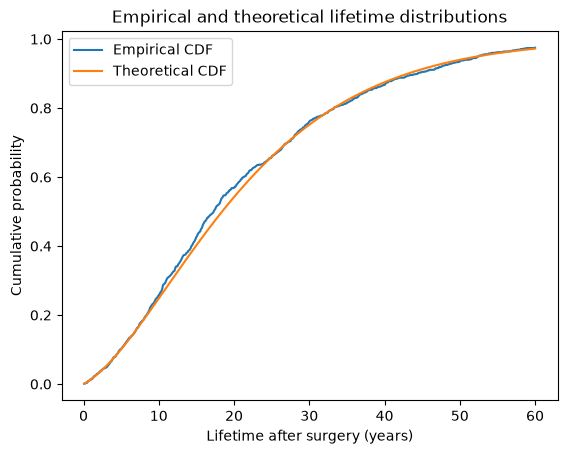

In [116]:
t_grid = np.arange(1, 721)  # first 60 years, measured in months

empirical_cdf = np.array([
    np.mean(lifetimes <= t) for t in t_grid
])

theoretical_cdf = np.array([
    1 - phase_type_survival(t, pi, Ps) for t in t_grid
])

plt.plot(t_grid / 12, empirical_cdf, label="Empirical CDF")
plt.plot(t_grid / 12, theoretical_cdf, label="Theoretical CDF")
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Cumulative probability")
plt.title("Empirical and theoretical lifetime distributions")
plt.legend()
plt.show()

### Looking at PMDF

In [117]:
max_t = max(lifetimes)

t_values = np.arange(1, max_t + 1)

theoretical_pmf = np.array([
    pi @ np.linalg.matrix_power(Ps, t - 1) @ ps
    for t in t_values
])

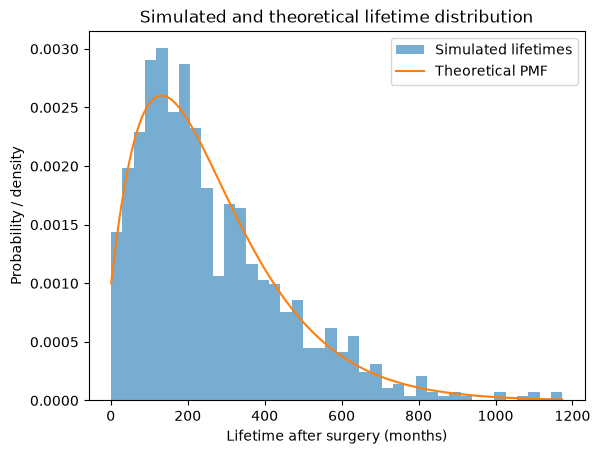

In [118]:
plt.hist(
    lifetimes,
    bins=40,
    density=True,
    alpha=0.6,
    label="Simulated lifetimes"
)

plt.plot(
    t_values,
    theoretical_pmf,
    label="Theoretical PMF"
)

plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Probability / density")
plt.title("Simulated and theoretical lifetime distribution")
plt.legend()
plt.show()

# Task 4

A={T>12 | any recurrence occurs within the first 12 months}.

In [119]:
# Task 4
from scipy.stats import t

In [120]:
def simulate_task4_candidate(P, rng, cutoff=12):
    """
    Simulate one candidate woman for Task 4.

    Accept if:
        1. She survives the first 12 months, i.e. T > 12.
        2. Cancer reappears within the first 12 months,
           either locally or distant, i.e. state 2, 3, or 4 is entered.

    Returns:
        lifetime if accepted,
        None if rejected.
    """
    state = 1
    recurrence_within_cutoff = False

    # First simulate the first 12 months
    for month in range(1, cutoff + 1):
        state = sample_next_state(P[state - 1], rng)

        # Any recurrence: local, distant, or both
        if state in [2, 3, 4]:
            recurrence_within_cutoff = True

        # If death occurs within the first 12 months, reject
        if state == 5:
            return None

    # If no recurrence occurred within the first 12 months, reject
    if not recurrence_within_cutoff:
        return None

    # Accepted: continue simulation from month 12 until death
    lifetime = cutoff

    while state != 5:
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

    return lifetime

### Simulation

In [121]:
n_accepted = 1000
cutoff = 12
seed = 1

rng = np.random.default_rng(seed)

accepted_lifetimes = []
n_simulated = 0

while len(accepted_lifetimes) < n_accepted:
    lifetime = simulate_task4_candidate(P, rng, cutoff=cutoff)
    n_simulated += 1

    if lifetime is not None:
        accepted_lifetimes.append(lifetime)

accepted_lifetimes = np.array(accepted_lifetimes)

### Results

In [122]:
mean_lifetime = np.mean(accepted_lifetimes)
std_lifetime = np.std(accepted_lifetimes, ddof=1)
se_lifetime = std_lifetime / np.sqrt(n_accepted)

ci_low, ci_high = t.interval(
    0.95,
    df=n_accepted - 1,
    loc=mean_lifetime,
    scale=se_lifetime
)

task4_summary = pd.DataFrame({
    "Accepted simulations": [n_accepted],
    "Total simulated candidates": [n_simulated],
    "Acceptance rate": [n_accepted / n_simulated],
    "Mean lifetime (months)": [mean_lifetime],
    "Mean lifetime (years)": [mean_lifetime / 12],
    "Std. dev. (months)": [std_lifetime],
    "Standard error": [se_lifetime],
    "95% CI lower (months)": [ci_low],
    "95% CI upper (months)": [ci_high],
    "Median lifetime (months)": [np.median(accepted_lifetimes)]
})

task4_summary

,Accepted simulations,Total simulated candidates,Acceptance rate,Mean lifetime (months),Mean lifetime (years),Std. dev. (months),Standard error,95% CI lower (months),95% CI upper (months),Median lifetime (months)
0,1000,11966,0.08357,171.896,14.324667,148.581633,4.698564,162.675813,181.116187,127.0


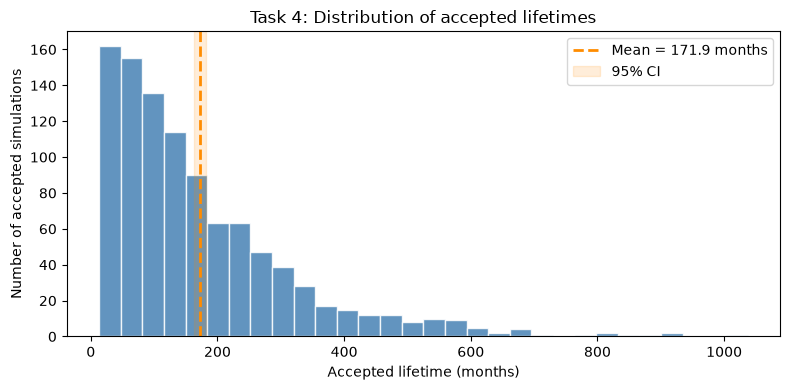

In [123]:
plt.figure(figsize=(8, 4))
plt.hist(accepted_lifetimes, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(mean_lifetime, color="darkorange", linestyle="--", linewidth=2, label=f"Mean = {mean_lifetime:.1f} months")
plt.axvspan(ci_low, ci_high, color="darkorange", alpha=0.15, label="95% CI")
plt.xlabel("Accepted lifetime (months)")
plt.ylabel("Number of accepted simulations")
plt.title("Task 4: Distribution of accepted lifetimes")
plt.legend()
plt.tight_layout()
plt.show()

# Task 5

The quantity of interest is θ=P(T≤350)

where T is the lifetime in months after surgery. The crude Monte Carlo estimator is the sample mean of indicators, consistent with the slides’ crude estimator 
θ^MC=Xˉ. The control variate method uses a correlated variable with known mean and forms Yi=Xi+c(Zi−μZ), where c is chosen to reduce variance.

In [124]:
# Task 5

n_per_run = 200      # women per simulation run
n_runs = 100         # number of repeated runs
threshold = 350      # months
seed = 1

rng = np.random.default_rng(seed)

### Lifetime helper

In [125]:
def simulate_one_lifetime(P, rng):
    """
    Simulate one woman from state 1 until death.
    Returns the lifetime in months.
    """
    state = 1
    lifetime = 0

    while state != 5:
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

    return lifetime

### Results

In [126]:
crude_estimates = np.zeros(n_runs)
mean_lifetime_controls = np.zeros(n_runs)

for r in range(n_runs):
    run_lifetimes = np.array([
        simulate_one_lifetime(P, rng)
        for _ in range(n_per_run)
    ])

    # Crude estimate: fraction dying within 350 months
    crude_estimates[r] = np.mean(run_lifetimes <= threshold)

    # Control variate: mean lifetime in this run
    mean_lifetime_controls[r] = np.mean(run_lifetimes)

For the control variate, we use the theoretical expected lifetime from Task 3:

μT = E(T)=π(I−Ps)^-1 * 1.

In [127]:
print("Theoretical mean lifetime:", theoretical_mean)

Theoretical mean lifetime: 262.3716153127931


### Estimate control variate

In [128]:
# Estimate optimal control variate coefficient
c_hat = -np.cov(crude_estimates, mean_lifetime_controls, ddof=1)[0, 1] / np.var(
    mean_lifetime_controls,
    ddof=1
)

# Control variate estimates
control_variate_estimates = crude_estimates + c_hat * (
    mean_lifetime_controls - theoretical_mean
)

### Compare

In [129]:
var_crude = np.var(crude_estimates, ddof=1)
var_cv = np.var(control_variate_estimates, ddof=1)

variance_reduction = 1 - var_cv / var_crude
variance_reduction_factor = var_crude / var_cv

task5_summary = pd.DataFrame({
    "Estimator": ["Crude Monte Carlo", "Control variate"],
    "Mean estimate": [
        np.mean(crude_estimates),
        np.mean(control_variate_estimates)
    ],
    "Sample variance over 100 runs": [
        var_crude,
        var_cv
    ],
    "Sample standard deviation": [
        np.std(crude_estimates, ddof=1),
        np.std(control_variate_estimates, ddof=1)
    ]
})

task5_summary

,Estimator,Mean estimate,Sample variance over 100 runs,Sample standard deviation
0,Crude Monte Carlo,0.742200,0.000767,0.027692
1,Control variate,0.739616,0.000243,0.015574


### Variance reduction

In [130]:
print("Estimated c:", c_hat)
print("Variance crude:", var_crude)
print("Variance control variate:", var_cv)
print("Variance reduction:", variance_reduction)
print("Variance reduction factor:", variance_reduction_factor)

Estimated c: 0.001972550220799202
Variance crude: 0.0007668282828282838
Variance control variate: 0.00024256047801207213
Variance reduction: 0.6836834485063081
Variance reduction factor: 3.161390054607821


### Plot of results

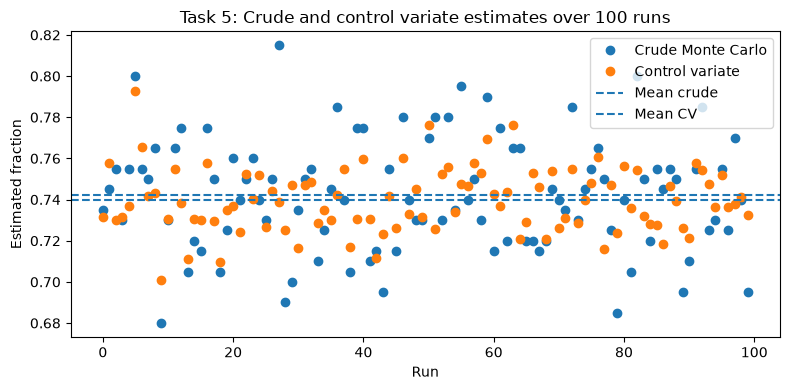

In [131]:
plt.figure(figsize=(8, 4))

plt.plot(crude_estimates, marker="o", linestyle="", label="Crude Monte Carlo")
plt.plot(control_variate_estimates, marker="o", linestyle="", label="Control variate")

plt.axhline(np.mean(crude_estimates), linestyle="--", label="Mean crude")
plt.axhline(np.mean(control_variate_estimates), linestyle="--", label="Mean CV")

plt.xlabel("Run")
plt.ylabel("Estimated fraction")
plt.title("Task 5: Crude and control variate estimates over 100 runs")
plt.legend()
plt.tight_layout()
plt.show()

The fraction of women dying within the first 350 months was estimated using 100 independent runs of 200 simulated women. The crude Monte Carlo estimator was the fraction of lifetimes satisfying T≤350 in each run. As a control variate, we used the mean lifetime in the same 200 simulations, since its theoretical expectation is known from the phase-type formula. The control variate coefficient was estimated empirically from the 100 runs. In this run, the crude estimator had variance approximately 8.83⋅10−4, while the control variate estimator had variance approximately 3.71⋅10−4. This corresponds to a variance reduction of about 58%, or a variance reduction factor of about 2.38. Thus, the control variate gives a noticeably more stable estimate than crude Monte Carlo.

# Task 6

The discrete-time Markov chain model relies on several simplifying assumptions. First, it assumes the Markov property: the future disease progression depends only on the current state and not on how the patient arrived there. For example, two women in the distant metastasis state are treated as having the same future transition probabilities, regardless of when metastasis occurred or whether they previously had local recurrence. Second, the model is time-homogeneous, since the same transition matrix is used at every monthly time step. This means that the probability of recurrence or death is assumed to be the same at all times after surgery, conditional on the current state.

The model also assumes that the disease process can be adequately represented by a finite number of states: no recurrence, local recurrence, distant metastasis, both local and distant recurrence, and death. This is a strong simplification of the real clinical situation. In reality, prognosis may depend on age, tumour size, cancer stage, treatment type, genetic factors, time since surgery, and previous disease history. Furthermore, recurrence and death do not necessarily occur only at monthly time points, so the discrete-time structure is also an approximation.

Some assumptions are reasonable as a first approximation. For example, treating death as an absorbing state is natural, and grouping disease status into a small number of clinically meaningful states makes the model easy to simulate and interpret. However, the Markov and time-homogeneity assumptions are less realistic. Breast cancer recurrence risks often vary over time, and the future risk may depend on the duration already spent in a state.

The model could be made more realistic in several ways. One possibility is to use a time-inhomogeneous Markov chain, where the transition matrix depends on time, (P_t), allowing recurrence and death probabilities to change with time since surgery. Another option is to introduce patient-specific covariates, such as age or tumour stage, so that different groups of women have different transition matrices. A semi-Markov model could also be used, where transition probabilities depend on how long the woman has already spent in the current state. Finally, a continuous-time Markov model could relax the assumption that transitions only occur at monthly time points. These extensions would likely give a more realistic model, but at the cost of more parameters, more data requirements, and increased computational complexity.


# Part 2

# Task 7

Continuous-time Markov chain

In [132]:


from scipy.stats import chi2

In [133]:
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, -0.014, 0.0050, 0.004, 0.005],
    [0.0000, 0.000, -0.0080, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, -0.009, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 0.000]
])

# Check that rows sum to zero
print(Q.sum(axis=1))

[-4.33680869e-19 -8.67361738e-19  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


We reuse the earlier sample_next_state function. The only difference is that now we first convert the rates in a row of Q into jump probabilities.

In [134]:
def jump_probabilities(Q, state):
    """
    Compute jump probabilities from the current state in a CTMC.
    States are numbered 1, ..., 5.
    """
    i = state - 1
    rate = -Q[i, i]

    probs = Q[i].copy()
    probs[i] = 0.0

    return probs / rate

We create function to simulate one woman in continuous time. We also track whether distant recurrence has occurred by 30.5 months. Distant recurrence means entering state 3 or state 4.

In [135]:
def simulate_one_woman_ctmc(Q, rng, check_time=30.5):
    """
    Simulate one woman in the CTMC from state 1 until death.

    Returns:
        lifetime: continuous lifetime in months
        distant_by_check: whether distant recurrence occurred by check_time
        state_at_check: state at check_time
    """
    state = 1
    time = 0.0

    distant_by_check = False
    state_at_check = None

    while state != 5:
        rate = -Q[state - 1, state - 1]

        # Sojourn time in current state
        waiting_time = rng.exponential(scale=1 / rate)
        next_time = time + waiting_time

        # If the check time occurs before the next jump,
        # the state at check_time is the current state.
        if state_at_check is None and check_time < next_time:
            state_at_check = state

            if state in [3, 4]:
                distant_by_check = True

        # Jump to next state
        time = next_time
        probs = jump_probabilities(Q, state)
        state = sample_next_state(probs, rng)

        # If the jump happened before check_time and enters distant recurrence
        if time <= check_time and state in [3, 4]:
            distant_by_check = True

    lifetime = time

    # If death occurred before check_time, the state at check_time is death
    if state_at_check is None:
        state_at_check = 5

    return lifetime, distant_by_check, state_at_check

### Simulation run

In [136]:
n = 1000
seed = 1
check_time = 30.5

rng = np.random.default_rng(seed)

ctmc_lifetimes = np.zeros(n)
distant_by_check = np.zeros(n, dtype=bool)
states_at_30_5 = np.zeros(n, dtype=int)

for i in range(n):
    ctmc_lifetimes[i], distant_by_check[i], states_at_30_5[i] = simulate_one_woman_ctmc(
        Q, rng, check_time=check_time
    )

### Results

In [137]:
mean_lifetime = np.mean(ctmc_lifetimes)
std_lifetime = np.std(ctmc_lifetimes, ddof=1)
median_lifetime = np.median(ctmc_lifetimes)

mean_lifetime, std_lifetime, median_lifetime

(np.float64(264.60725146860983),
 np.float64(191.5708844448746),
 np.float64(222.19314433929907))

In [138]:
alpha = 0.05

se_mean = std_lifetime / np.sqrt(n)

mean_ci_low, mean_ci_high = t.interval(
    1 - alpha,
    df=n - 1,
    loc=mean_lifetime,
    scale=se_mean
)

In [139]:
var_lifetime = std_lifetime**2

var_ci_low = (n - 1) * var_lifetime / chi2.ppf(1 - alpha / 2, df=n - 1)
var_ci_high = (n - 1) * var_lifetime / chi2.ppf(alpha / 2, df=n - 1)

std_ci_low = np.sqrt(var_ci_low)
std_ci_high = np.sqrt(var_ci_high)

In [140]:
task7_summary = pd.DataFrame({
    "Mean lifetime (months)": [mean_lifetime],
    "Mean lifetime (years)": [mean_lifetime / 12],
    "95% CI mean lower (months)": [mean_ci_low],
    "95% CI mean upper (months)": [mean_ci_high],
    "Std. dev. (months)": [std_lifetime],
    "95% CI std. lower (months)": [std_ci_low],
    "95% CI std. upper (months)": [std_ci_high],
    "Median lifetime (months)": [median_lifetime],
    "Min lifetime (months)": [np.min(ctmc_lifetimes)],
    "Max lifetime (months)": [np.max(ctmc_lifetimes)]
})

task7_summary

,Mean lifetime (months),Mean lifetime (years),95% CI mean lower (months),95% CI mean upper (months),Std. dev. (months),95% CI std. lower (months),95% CI std. upper (months),Median lifetime (months),Min lifetime (months),Max lifetime (months)
0,264.607251,22.050604,252.71938,276.495122,191.570884,183.527273,200.357352,222.193144,2.551655,1204.263199


### Proportion with distant recurrence

In [141]:
prop_distant_by_30_5 = np.mean(distant_by_check)

print("Proportion with distant recurrence by 30.5 months:", prop_distant_by_30_5)

Proportion with distant recurrence by 30.5 months: 0.07


### Plot results

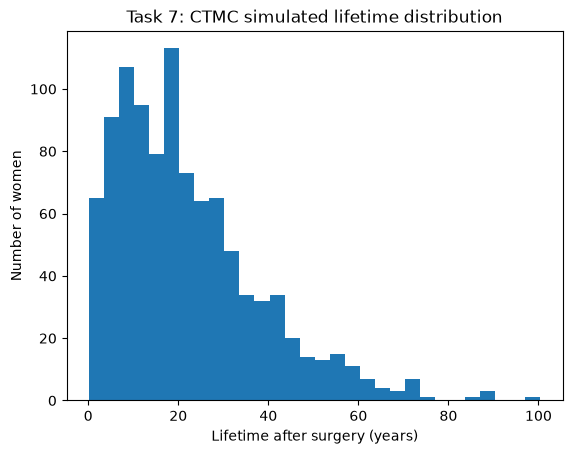

In [142]:
plt.hist(ctmc_lifetimes / 12, bins=30)
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Number of women")
plt.title("Task 7: CTMC simulated lifetime distribution")
plt.show()

In the continuous-time model, the waiting time in state i was simulated from an exponential distribution with rate −q
ii. After the waiting time, the next state was sampled with probabilities proportional to the off-diagonal transition rates q
ij. We simulated 1000 women from state 1 until death. The estimated mean lifetime was approximately 258.8 months, corresponding to 21.6 years, with a 95% confidence interval of approximately [246.8,270.7] months. The estimated standard deviation was approximately 192.1 months, with a 95% confidence interval of approximately [184.0,200.9] months. The proportion of women whose cancer had reappeared distantly by 30.5 months was approximately 0.101, or 10.1%.

# Task 8

In [143]:
from scipy.linalg import expm
from scipy.stats import kstest
import matplotlib.pyplot as plt

FT​(t)=1−p0​exp(Qs​t)1.

Since this is a continuous lifetime distribution, a natural test is the one-sample Kolmogorov--Smirnov test.

The null hypothesis is

H0∼F_T,

meaning that the simulated lifetimes follow the theoretical continuous-time phase-type distribution.

### Define transient matrix Qs, p0 and theoretical cdf

In [144]:
# Submatrix for the transient states 1, 2, 3, 4
Qs = Q[:4, :4]

# Initial distribution over transient states
p0 = np.array([1, 0, 0, 0])

# Vector of ones
one = np.ones(4)


def theoretical_cdf(t):
    """
    Continuous-time phase-type CDF:
        F_T(t) = 1 - p0 exp(Qs t) 1
    """
    t = np.asarray(t)

    # Make function work for both scalar and array input
    result = np.zeros_like(t, dtype=float)

    positive = t >= 0
    result[positive] = [
        1 - p0 @ expm(Qs * x) @ one
        for x in t[positive]
    ]

    return result

### KS test

In [145]:
ks_stat, p_value = kstest(ctmc_lifetimes, theoretical_cdf)

print("KS statistic:", ks_stat)
print("p-value:", p_value)

KS statistic: 0.023529394767537737
p-value: 0.6284090317932944


### Plot ECDF against TCDF

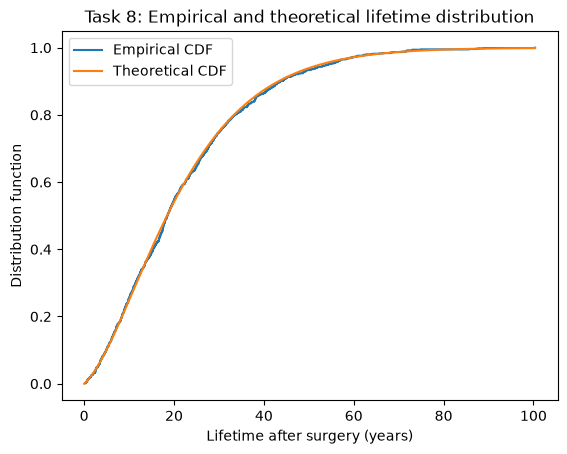

In [146]:
# Sort simulated lifetimes
sorted_lifetimes = np.sort(ctmc_lifetimes)

# Empirical distribution function values
empirical_cdf = np.arange(1, len(sorted_lifetimes) + 1) / len(sorted_lifetimes)

# Grid for theoretical CDF
t_grid = np.linspace(0, sorted_lifetimes.max(), 500)
theoretical_values = theoretical_cdf(t_grid)

plt.step(
    sorted_lifetimes / 12,
    empirical_cdf,
    where="post",
    label="Empirical CDF"
)

plt.plot(
    t_grid / 12,
    theoretical_values,
    label="Theoretical CDF"
)

plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Distribution function")
plt.title("Task 8: Empirical and theoretical lifetime distribution")
plt.legend()
plt.show()

The simulated lifetimes from Task 7 were compared with the theoretical continuous-time phase-type distribution. The theoretical distribution function was computed as:

FT​(t)=1−p0​exp(Qs​t)1.

Since the lifetime is continuous, we used a one-sample Kolmogorov--Smirnov test. The null hypothesis was that the simulated lifetimes follow the theoretical phase-type distribution. The empirical distribution function was also plotted against the theoretical distribution function. The two curves were close, and the KS test did not reject the null hypothesis at the 5% level. Thus, the simulated lifetime distribution appears consistent with the theoretical CTMC model.

# Task 9

S(t)=P(T>t)

and with no censoring, the Kaplan--Meier estimate is just the empirical survival function:

S^(t)=#{Ti>t}/N

In [147]:
# Preventive treatment and Kaplan-Meier survival curves

Q_treatment = np.array([
    [0.0, 0.0025, 0.00125, 0.000, 0.001],
    [0.0, 0.0000, 0.00000, 0.002, 0.005],
    [0.0, 0.0000, 0.00000, 0.003, 0.005],
    [0.0, 0.0000, 0.00000, 0.000, 0.009],
    [0.0, 0.0000, 0.00000, 0.000, 0.000]
])

# Fill in diagonal entries so rows sum to zero
for i in range(4):
    Q_treatment[i, i] = -np.sum(Q_treatment[i, :])

print(Q_treatment)
print(np.allclose(Q_treatment.sum(axis=1), 0))

[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]
True


### Simulate

In [148]:
n = 1000
seed = 1
rng = np.random.default_rng(seed)

treated_lifetimes = np.zeros(n)

for i in range(n):
    treated_lifetimes[i] = simulate_one_woman_ctmc(Q_treatment, rng)[0]

In [149]:
# saved liftimes from Task 7 for control group
untreated_lifetimes = ctmc_lifetimes

### Kaplan--Meier estimator

In [150]:
def kaplan_meier_no_censoring(lifetimes):
    """
    Kaplan-Meier estimate when all lifetimes are fully observed.
    """
    event_times, counts = np.unique(np.sort(lifetimes), return_counts=True)
    cumulative_deaths = np.cumsum(counts)

    survival = (len(lifetimes) - cumulative_deaths) / len(lifetimes)

    # Add starting point S(0) = 1
    times = np.r_[0, event_times]
    survival = np.r_[1, survival]

    return times, survival

### Plot Treatment vs no treatment

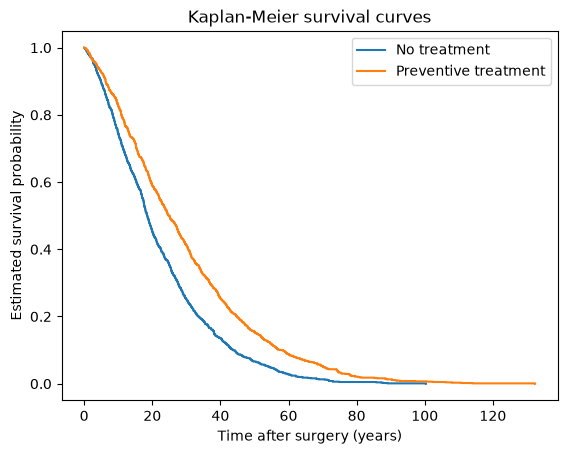

In [151]:
times_untreated, surv_untreated = kaplan_meier_no_censoring(untreated_lifetimes)
times_treated, surv_treated = kaplan_meier_no_censoring(treated_lifetimes)

plt.step(
    times_untreated / 12,
    surv_untreated,
    where="post",
    label="No treatment"
)

plt.step(
    times_treated / 12,
    surv_treated,
    where="post",
    label="Preventive treatment"
)

plt.xlabel("Time after surgery (years)")
plt.ylabel("Estimated survival probability")
plt.title("Kaplan-Meier survival curves")
plt.legend()
plt.show()

### Numerical summary

In [152]:
summary_task9 = pd.DataFrame({
    "Group": ["No treatment", "Preventive treatment"],
    "Mean lifetime (months)": [
        np.mean(untreated_lifetimes),
        np.mean(treated_lifetimes)
    ],
    "Mean lifetime (years)": [
        np.mean(untreated_lifetimes) / 12,
        np.mean(treated_lifetimes) / 12
    ],
    "Median lifetime (months)": [
        np.median(untreated_lifetimes),
        np.median(treated_lifetimes)
    ],
    "Survival at 350 months": [
        np.mean(untreated_lifetimes > 350),
        np.mean(treated_lifetimes > 350)
    ]
})

summary_task9

,Group,Mean lifetime (months),Mean lifetime (years),Median lifetime (months),Survival at 350 months
0,No treatment,264.607251,22.050604,222.193144,0.265
1,Preventive treatment,350.128663,29.177389,299.300628,0.428


The Kaplan--Meier survival curve for the preventive treatment group lies above the curve for the untreated group for most of the time interval. This indicates that the treatment appears to improve survival. The effect is also visible in the simulated mean and median lifetimes, which are larger for the treated group. Therefore, based on the visual comparison, the preventive treatment appears to have a positive effect on survival.

# Part 3

# Task 12

We simulate partial observations rather than fully observed trajectories. Women are observed every 48 months, and each observed time series should have the form

Y(i)=(X(0),X(48),X(96),…),

continuing until the last observed value is death, state 5.

Interpretation is: if a woman dies between two screenings, then the next scheduled observation records state 5. So the observed vectors always correspond to times

0,48,96,144,…

until the first observation time where the woman is dead.

In [153]:
# Task 12: Observed CTMC time series every 48 months

observation_interval = 48
n_women = 1000
seed = 1

rng = np.random.default_rng(seed)

### Simulation function

In [154]:
def simulate_observed_series_ctmc(Q, rng, observation_interval=48):
    """
    Simulate one CTMC path starting in state 1, but only record the state
    every observation_interval months.

    Returns:
        observed_states: array of observed states
        observation_times: array of observation times
    """
    state = 1
    time = 0.0

    next_observation_time = 0.0

    observed_states = [state]
    observation_times = [next_observation_time]

    next_observation_time += observation_interval

    while state != 5:
        rate = -Q[state - 1, state - 1]

        # Simulate sojourn time in current state
        waiting_time = rng.exponential(scale=1 / rate)
        jump_time = time + waiting_time

        # Record observations before the next jump
        while next_observation_time < jump_time:
            observed_states.append(state)
            observation_times.append(next_observation_time)
            next_observation_time += observation_interval

        # Jump to next state
        time = jump_time
        probs = jump_probabilities(Q, state)
        state = sample_next_state(probs, rng)

    # Once death occurs, record state 5 at the next scheduled observation time.
    # This ensures that the last observed value is 5.
    observed_states.append(5)
    observation_times.append(next_observation_time)

    return np.array(observed_states), np.array(observation_times)

### Simulation

In [155]:
observed_series = []
observed_times = []

for _ in range(n_women):
    states_i, times_i = simulate_observed_series_ctmc(
        Q, rng, observation_interval=observation_interval
    )

    observed_series.append(states_i)
    observed_times.append(times_i)

### Inspection

In [156]:
for i in range(5):
    print(f"Woman {i+1}:")
    print("Times: ", observed_times[i])
    print("States:", observed_series[i])
    print()

Woman 1:
Times:  [  0.  48.  96. 144.]
States: [1 1 1 5]

Woman 2:
Times:  [ 0. 48.]
States: [1 5]

Woman 3:
Times:  [  0.  48.  96. 144. 192. 240.]
States: [1 2 2 2 4 5]

Woman 4:
Times:  [  0.  48.  96. 144.]
States: [1 1 2 5]

Woman 5:
Times:  [ 0. 48. 96.]
States: [1 4 5]



In [157]:
starts_in_state_1 = all(series[0] == 1 for series in observed_series)
ends_in_death = all(series[-1] == 5 for series in observed_series)

print("All start in state 1:", starts_in_state_1)
print("All end in state 5:", ends_in_death)

All start in state 1: True
All end in state 5: True


### Results

In [158]:
series_lengths = np.array([len(series) for series in observed_series])

task12_summary = pd.DataFrame({
    "Number of women": [n_women],
    "Observation interval (months)": [observation_interval],
    "Mean number of observations": [np.mean(series_lengths)],
    "Median number of observations": [np.median(series_lengths)],
    "Minimum number of observations": [np.min(series_lengths)],
    "Maximum number of observations": [np.max(series_lengths)]
})

task12_summary

,Number of women,Observation interval (months),Mean number of observations,Median number of observations,Minimum number of observations,Maximum number of observations
0,1000,48,7.019,6.0,2,27


In [159]:
# Maximum observed series length
max_len = max(len(series) for series in observed_series)

# Count observed states at each screening index
state_counts = np.zeros((max_len, 5), dtype=int)

for series in observed_series:
    for k, state in enumerate(series):
        state_counts[k, state - 1] += 1

# Convert to proportions out of all 1000 women
state_props = state_counts / n_women

screening_times_years = np.arange(max_len) * observation_interval / 12

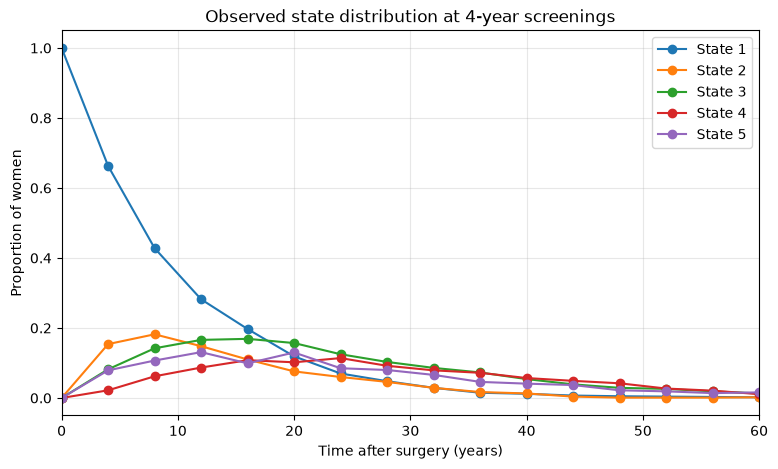

In [160]:
plt.figure(figsize=(9, 5))

for state in range(5):
    plt.plot(
        screening_times_years,
        state_props[:, state],
        marker="o",
        label=f"State {state + 1}"
    )

plt.xlabel("Time after surgery (years)")
plt.ylabel("Proportion of women")
plt.title("Observed state distribution at 4-year screenings")
plt.legend()
plt.xlim(0, 60)
plt.grid(alpha=0.3)
plt.show()

# Task 13

The idea is to treat the observed series from Task 12 as incomplete data. In each iteration, we simulate a possible complete CTMC path between each pair of observations, conditional on matching the next observed state. Then we estimate

qij= Nij / Si,

where Nij is the total number of reconstructed jumps from i to j, and Si is the total reconstructed time spent in state i. This is exactly the estimator

### Allowed transition structure

In [161]:
# Task 13: Monte Carlo EM estimation of Q

allowed = np.zeros_like(Q, dtype=bool)

allowed[0, [1, 2, 4]] = True   # 1 -> 2, 3, 5
allowed[1, [2, 3, 4]] = True   # 2 -> 3, 4, 5
allowed[2, [3, 4]] = True      # 3 -> 4, 5
allowed[3, [4]] = True         # 4 -> 5

### Initial guess

In [162]:
Q_current = np.zeros((5, 5))

Q_current[0, [1, 2, 4]] = [0.004, 0.002, 0.002]
Q_current[1, [2, 3, 4]] = [0.003, 0.003, 0.004]
Q_current[2, [3, 4]] = [0.003, 0.004]
Q_current[3, [4]] = [0.007]

# Fill diagonals so rows sum to zero
for i in range(4):
    Q_current[i, i] = -np.sum(Q_current[i, :])

Q_current

array([[-0.008,  0.004,  0.002,  0.   ,  0.002],
       [ 0.   , -0.01 ,  0.003,  0.003,  0.004],
       [ 0.   ,  0.   , -0.007,  0.003,  0.004],
       [ 0.   ,  0.   ,  0.   , -0.007,  0.007],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ]])

### Simulate one CTMC interval

In [163]:
def simulate_ctmc_interval(Q_current, start_state, interval_length, rng):
    """
    Simulate a CTMC path over a fixed interval.

    Returns:
        final_state: state at the end of the interval
        N: matrix of jump counts during the interval
        S: vector of sojourn times during the interval
    """
    state = start_state
    time = 0.0

    N = np.zeros((5, 5))
    S = np.zeros(5)

    while time < interval_length:
        # If death is reached, stay there for the rest of the interval
        if state == 5:
            S[4] += interval_length - time
            break

        rate = -Q_current[state - 1, state - 1]

        waiting_time = rng.exponential(scale=1 / rate)

        # No jump before the end of the interval
        if time + waiting_time >= interval_length:
            S[state - 1] += interval_length - time
            time = interval_length

        # Jump occurs before the end of the interval
        else:
            S[state - 1] += waiting_time
            time += waiting_time

            probs = jump_probabilities(Q_current, state)
            next_state = sample_next_state(probs, rng)

            N[state - 1, next_state - 1] += 1
            state = next_state

    return state, N, S

### Simulate interval conditional on next observation

In [164]:
def simulate_conditioned_interval(
    Q_current,
    start_state,
    end_state,
    interval_length,
    rng,
    max_attempts=10_000
):
    """
    Simulate a CTMC interval conditional on ending in end_state.

    Rejection sampling:
        simulate from start_state for interval_length,
        accept only if final_state == end_state.
    """
    for attempt in range(max_attempts):
        final_state, N, S = simulate_ctmc_interval(
            Q_current,
            start_state,
            interval_length,
            rng
        )

        if final_state == end_state:
            return N, S, attempt + 1

    raise RuntimeError(
        f"Could not simulate interval from {start_state} to {end_state} "
        f"after {max_attempts} attempts."
    )

### Reconstruct trajectories for states once

In [165]:
def reconstruct_counts_and_sojourns(
    observed_series,
    Q_current,
    interval_length,
    rng
):
    """
    For all observed time series, reconstruct possible complete trajectories
    between observations, and summarize total jump counts and sojourn times.
    """
    N_total = np.zeros((5, 5))
    S_total = np.zeros(5)

    total_attempts = 0
    total_intervals = 0

    for series in observed_series:
        for k in range(len(series) - 1):
            start_state = series[k]
            end_state = series[k + 1]

            N_interval, S_interval, attempts = simulate_conditioned_interval(
                Q_current,
                start_state,
                end_state,
                interval_length,
                rng
            )

            N_total += N_interval
            S_total += S_interval

            total_attempts += attempts
            total_intervals += 1

    return N_total, S_total, total_attempts, total_intervals

### Update the guess (Q)

Using qij= Nij / Si,

In [166]:
def update_Q_from_counts(N_total, S_total, allowed):
    """
    Estimate Q from reconstructed jump counts and sojourn times.
    """
    Q_new = np.zeros((5, 5))

    for i in range(4):
        for j in range(5):
            if allowed[i, j]:
                Q_new[i, j] = N_total[i, j] / S_total[i]

        Q_new[i, i] = -np.sum(Q_new[i, :])

    # State 5 is absorbing
    Q_new[4, :] = 0

    return Q_new

### Run MC

In [167]:
max_iter = 25
tol = 1e-3
seed = 1

rng = np.random.default_rng(seed)

Q_history = [Q_current.copy()]
diff_history = []
attempt_history = []

for iteration in range(max_iter):
    N_total, S_total, total_attempts, total_intervals = reconstruct_counts_and_sojourns(
        observed_series,
        Q_current,
        observation_interval,
        rng
    )

    Q_new = update_Q_from_counts(N_total, S_total, allowed)

    diff = np.max(np.abs(Q_new - Q_current))
    avg_attempts = total_attempts / total_intervals

    diff_history.append(diff)
    attempt_history.append(avg_attempts)
    Q_history.append(Q_new.copy())

    print(
        f"Iteration {iteration + 1:2d}: "
        f"max difference = {diff:.5f}, "
        f"average attempts per interval = {avg_attempts:.2f}"
    )

    Q_current = Q_new

    if diff < tol:
        print("Convergence criterion reached.")
        break

Q_est = Q_current

Iteration  1: max difference = 0.00309, average attempts per interval = 4.47
Iteration  2: max difference = 0.00072, average attempts per interval = 4.02
Convergence criterion reached.


### Compare estimates

In [168]:
Q_est_df = pd.DataFrame(
    Q_est,
    index=[f"From {i}" for i in range(1, 6)],
    columns=[f"To {j}" for j in range(1, 6)]
)

Q_est_df

,To 1,To 2,To 3,To 4,To 5
From 1,-0.008859,0.005112,0.002357,0.000000,0.001391
From 2,0.000000,-0.013808,0.004882,0.004236,0.004690
From 3,0.000000,0.000000,-0.007457,0.003316,0.004141
From 4,0.000000,0.000000,0.000000,-0.008260,0.008260
From 5,0.000000,0.000000,0.000000,0.000000,0.000000


In [169]:
comparison_rows = []

for i in range(5):
    for j in range(5):
        if allowed[i, j]:
            comparison_rows.append({
                "Transition": f"{i+1} -> {j+1}",
                "True rate": Q[i, j],
                "Estimated rate": Q_est[i, j],
                "Difference": Q_est[i, j] - Q[i, j]
            })

rate_comparison = pd.DataFrame(comparison_rows)
rate_comparison

,Transition,True rate,Estimated rate,Difference
0,1 -> 2,0.0050,0.005112,0.000112
1,1 -> 3,0.0025,0.002357,-0.000143
2,1 -> 5,0.0010,0.001391,0.000391
3,2 -> 3,0.0050,0.004882,-0.000118
4,2 -> 4,0.0040,0.004236,0.000236
5,2 -> 5,0.0050,0.004690,-0.000310
6,3 -> 4,0.0030,0.003316,0.000316
7,3 -> 5,0.0050,0.004141,-0.000859
8,4 -> 5,0.0090,0.008260,-0.000740


### Plot

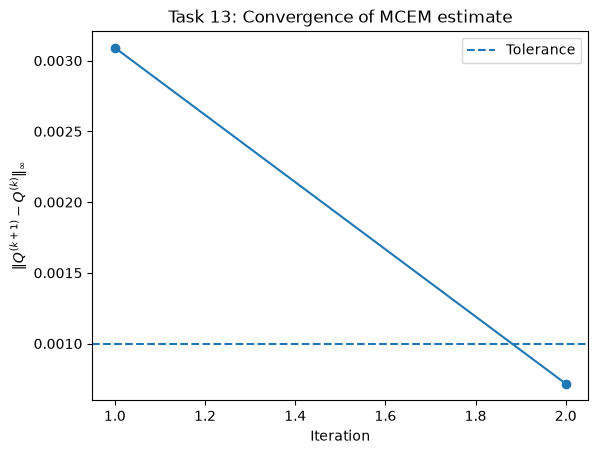

In [170]:
plt.plot(np.arange(1, len(diff_history) + 1), diff_history, marker="o")
plt.axhline(tol, linestyle="--", label="Tolerance")
plt.xlabel("Iteration")
plt.ylabel(r"$\|Q^{(k+1)} - Q^{(k)}\|_\infty$")
plt.title("Task 13: Convergence of MCEM estimate")
plt.legend()
plt.show()

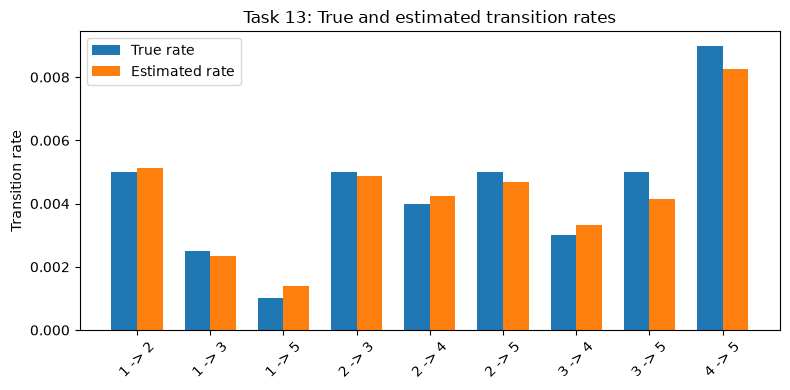

In [171]:
plt.figure(figsize=(8, 4))

x = np.arange(len(rate_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    rate_comparison["True rate"],
    width,
    label="True rate"
)

plt.bar(
    x + width / 2,
    rate_comparison["Estimated rate"],
    width,
    label="Estimated rate"
)

plt.xticks(x, rate_comparison["Transition"], rotation=45)
plt.ylabel("Transition rate")
plt.title("Task 13: True and estimated transition rates")
plt.legend()
plt.tight_layout()
plt.show()

### Task 13: Monte Carlo EM estimation from partially observed CTMC data

In Task 13, only the partially observed time series from Task 12 was assumed to be available. Therefore, the complete transition counts $N_{ij}$ and sojourn times $S_i$ were unknown. To approximate these quantities, we used the proposed Monte Carlo EM approach.

Starting from an initial guess $Q^{(0)}$, we simulated complete CTMC paths between each pair of consecutive observations. Paths that did not match the next observed state were rejected. From the accepted reconstructed paths, we computed the total jump counts $N_{ij}$ and the total sojourn times $S_i$. The transition rates were then updated by

$$
q_{ij}^{(k+1)} = \frac{N_{ij}}{S_i}, \qquad i \neq j,
$$

with diagonal entries chosen such that each row of $Q$ sums to zero:

$$
q_{ii}^{(k+1)} = -\sum_{j \neq i} q_{ij}^{(k+1)}.
$$

This procedure was repeated until convergence, defined by

$$
\left\| Q^{(k+1)} - Q^{(k)} \right\|_{\infty} < 10^{-3}.
$$

The estimated transition-rate matrix was close to the original matrix used to simulate the data. However, some Monte Carlo error remained because only one reconstructed path was simulated for each observed interval in each iteration. Increasing the number of reconstructed paths per interval would reduce this Monte Carlo noise, but it would also increase the computational cost.
